In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Ονοματεπώνυμο: Πέτρος Ματσούκης, ΑΜ: 1115202100099, Ονοματεπώνυμο: Γιώργος Κορύλλος, ΑΜ: 1115202100069

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import folium
import random
import numpy as np
from wordcloud import WordCloud
from sklearn.feature_extraction import text
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
from nltk.metrics import BigramAssocMeasures
from nltk.collocations import BigramCollocationFinder

def cleaning(df):
  #column 'bathrooms' has nothing
  df.drop(columns=['bathrooms'], inplace=True)

  #bedrooms, beds, accommodates must be from 1 to 15 and all integers
  for col in df.columns:
    if col in ['bedrooms', 'beds', 'accommodates']:
      df.loc[(df[col] < 1) | (df[col] >= 16), col] = np.nan

  #minimum nights must be from 1 to 30
  df = df.loc[(df['minimum_nights'] <= 30) & (df['minimum_nights'] > 0)]

  #availability_365 must be from 0 to 365
  df = df.loc[(df['availability_365'] >= 0) & (df['availability_365'] <= 365)]

  for col in df.columns:
    if col in ['host_has_profile_pick', 'host_identity_verified', 'instant_bookable']:
      df = df.loc[(df[col] == 't') | (df[col] == 'f')]

  df = df.dropna()
  df = df.drop_duplicates()

  df['host_id'] = df['host_id'].astype(int)

  #make them integers
  for col in df.columns:
    if col in ['bedrooms', 'beds', 'accommodates']:
      df[col] = df[col].astype(int)

  #get rid of $ in column 'price' and convert all prices to numbers
  df['price'] = df['price'].str.replace('$', '')
  df['price'] = pd.to_numeric(df['price'], errors='coerce')
  return df

In [ ]:
listings_june_2023 = '/content/drive/MyDrive/2023/june/listings.csv'
listings_march_2023 = '/content/drive/MyDrive/2023/march/listings.csv'
listings_september_2023 = '/content/drive/MyDrive/2023/september/listings.csv'
listings0_june_2023 = '/content/drive/MyDrive/2023/june/listings0.csv'
listings0_march_2023 = '/content/drive/MyDrive/2023/march/listings0.csv'
listings0_september_2023 = '/content/drive/MyDrive/2023/september/listings0.csv'
reviews_june_2023 = '/content/drive/MyDrive/2023/june/reviews.csv'
reviews_march_2023 = '/content/drive/MyDrive/2023/march/reviews.csv'
reviews_september_2023 = '/content/drive/MyDrive/2023/september/reviews.csv'

columns = ['id', 'bedrooms', 'beds', 'review_scores_rating',
                     'number_of_reviews', 'neighbourhood', 'neighbourhood_cleansed', 'name', 'latitude',
                     'longitude', 'last_review', 'instant_bookable', 'host_id', 'host_since',
                     'host_response_rate', 'host_identity_verified', 'host_has_profile_pic',
                     'first_review', 'description', 'bathrooms',
                     'accommodates', 'amenities', 'room_type',
                     'property_type', 'price', 'availability_365', 'minimum_nights']

listings_june_2023_df = pd.read_csv(listings_june_2023, usecols=columns)
listings_march_2023_df = pd.read_csv(listings_march_2023, usecols=columns)
listings_september_2023_df = pd.read_csv(listings_september_2023, usecols=columns)
listings0_june_2023_df = pd.read_csv(listings0_june_2023)
listings0_march_2023_df = pd.read_csv(listings0_march_2023)
listings0_september_2023_df = pd.read_csv(listings0_september_2023)
reviews_june_2023_df = pd.read_csv(reviews_june_2023, nrows = 3000)
reviews_march_2023_df = pd.read_csv(reviews_march_2023, nrows = 3000)
reviews_september_2023_df = pd.read_csv(reviews_september_2023, nrows = 3000)

#extra column for month
listings_june_2023_df['month'] = 'june'
listings_march_2023_df['month'] = 'march'
listings_september_2023_df['month'] = 'september'

listings_2023_df = pd.concat([listings_june_2023_df, listings_march_2023_df,
                              listings_september_2023_df], ignore_index=True)
listings0_2023_df = pd.concat([listings0_june_2023_df,listings0_march_2023_df,
                              listings0_september_2023_df], ignore_index=True)
reviews_2023_df = pd.concat([reviews_june_2023_df, reviews_march_2023_df,
                              reviews_september_2023_df], ignore_index=True)

#clean
listings_2023_df = cleaning(listings_2023_df)

#make one csv for all months in a year
listings_2023_df.to_csv('train_2023.csv', index=False)

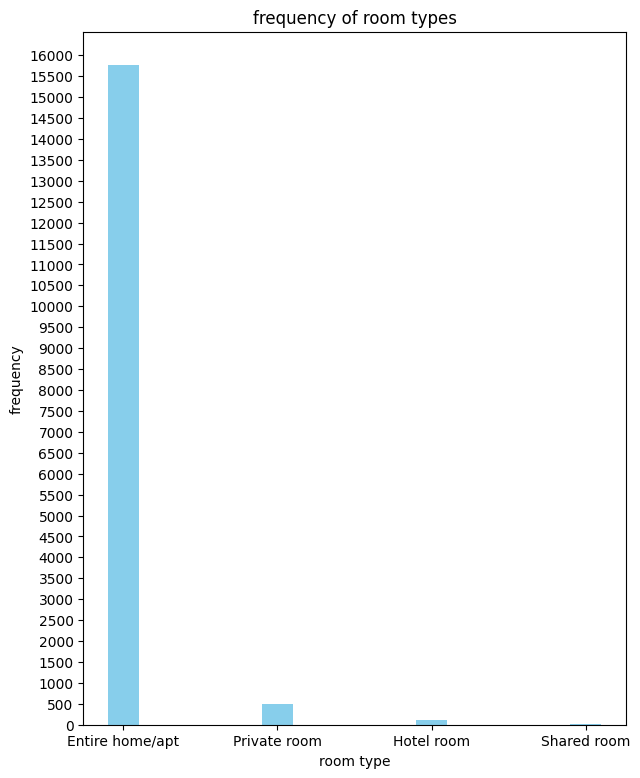

In [ ]:
#EROTIMA 1.1
df = pd.read_csv('train_2023.csv')

#count how many times every room_type exists
room_type_counts = df['room_type'].value_counts()

#make plot
plt.figure(figsize=(7, 9))
plt.bar(room_type_counts.index, room_type_counts.values, color='skyblue',width = 0.2)
plt.xlabel("room type")
plt.ylabel("frequency")
plt.title('frequency of room types')
max_y = room_type_counts.values.max()
plt.yticks(range(0, max_y+500, 500))

#save plot
plt.savefig('question_1_1.png')

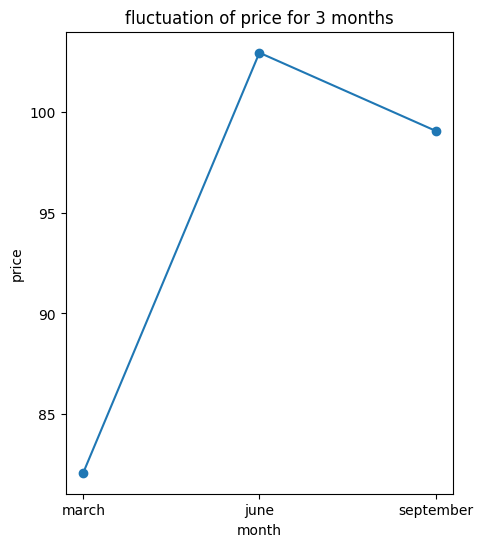

In [ ]:
#EROTIMA 1.2
df_mar_2019 = df[df['month'] == 'march']
df_jun_2019 = df[df['month'] == 'june']
df_sep_2019 = df[df['month'] == 'september']

mean_mar_2019 = df_mar_2019['price'].mean()
mean_jun_2019 = df_jun_2019['price'].mean()
mean_sep_2019 = df_sep_2019['price'].mean()

df_2019_range = pd.DataFrame({'month': ['march','june','september'],
                              'price':[mean_mar_2019, mean_jun_2019,
                                       mean_sep_2019]})
#make plot
plt.figure(figsize=(5, 6))
plt.plot(df_2019_range['month'], df_2019_range['price'], marker='o')
plt.xlabel('month')
plt.ylabel('price')
plt.title('fluctuation of price for 3 months')

#save plot
plt.savefig('question_1_2.png')


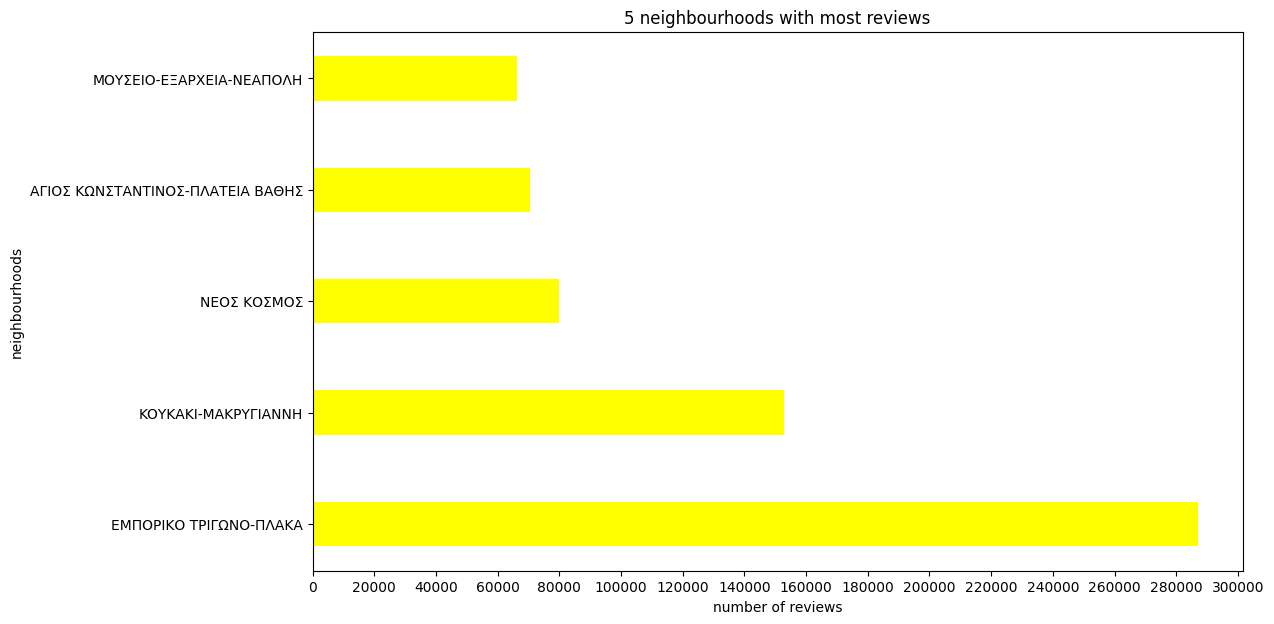

In [ ]:
#EROTIMA 1.3
df = pd.read_csv('train_2023.csv')

#get top 5 neighbourhoods with most reviews
neighbourhoods_with_reviews = df.groupby('neighbourhood_cleansed')['number_of_reviews'].sum()
top_five = neighbourhoods_with_reviews.nlargest(5)

#make plot
plt.figure(figsize=(12, 7))
plt.barh(top_five.index, top_five.values, color = 'yellow', height = 0.4)
plt.xlabel("number of reviews")
plt.ylabel("neighbourhoods")
plt.title('5 neighbourhoods with most reviews')
max_x = top_five.max()
plt.xticks(range(0, max_x+20000, 20000))

#save plot
plt.savefig('question_1_3.png')

In [ ]:
#EROTIMA 1.4
df = pd.read_csv('train_2023.csv')

neighbourhoods = df['neighbourhood_cleansed'].value_counts()
top_neighbourhood = neighbourhoods.head(1)
print(top_neighbourhood)

neighbourhood_cleansed
ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ    3263
Name: count, dtype: int64


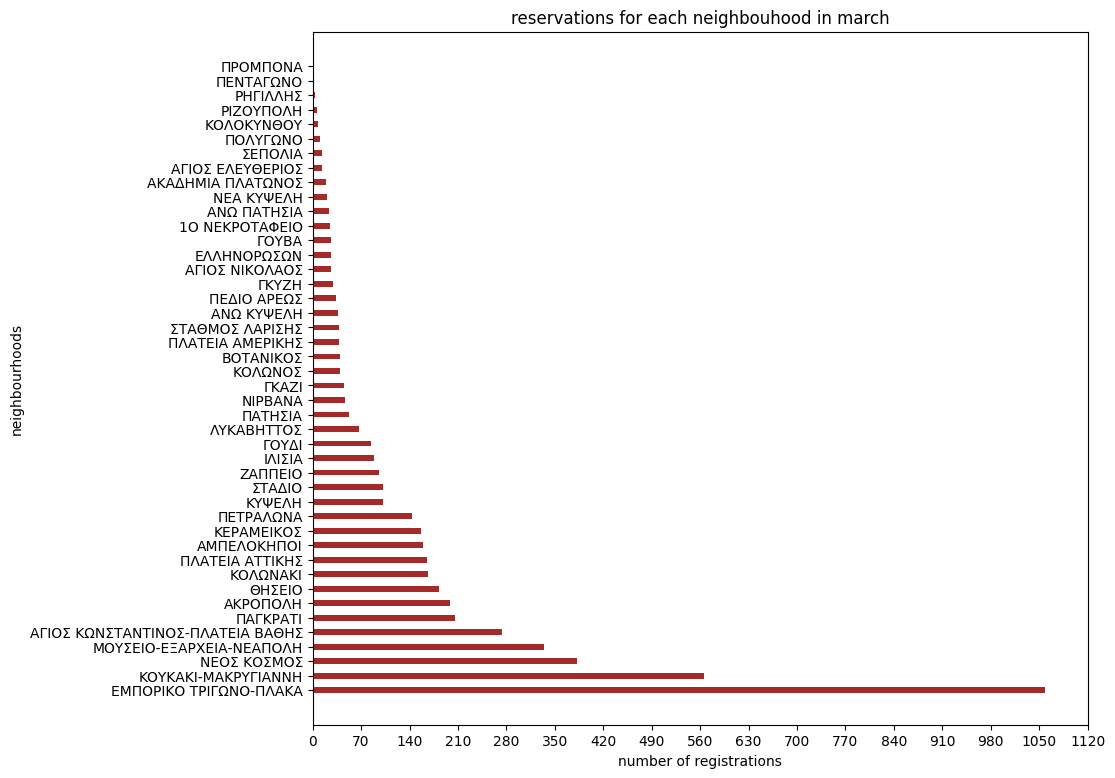

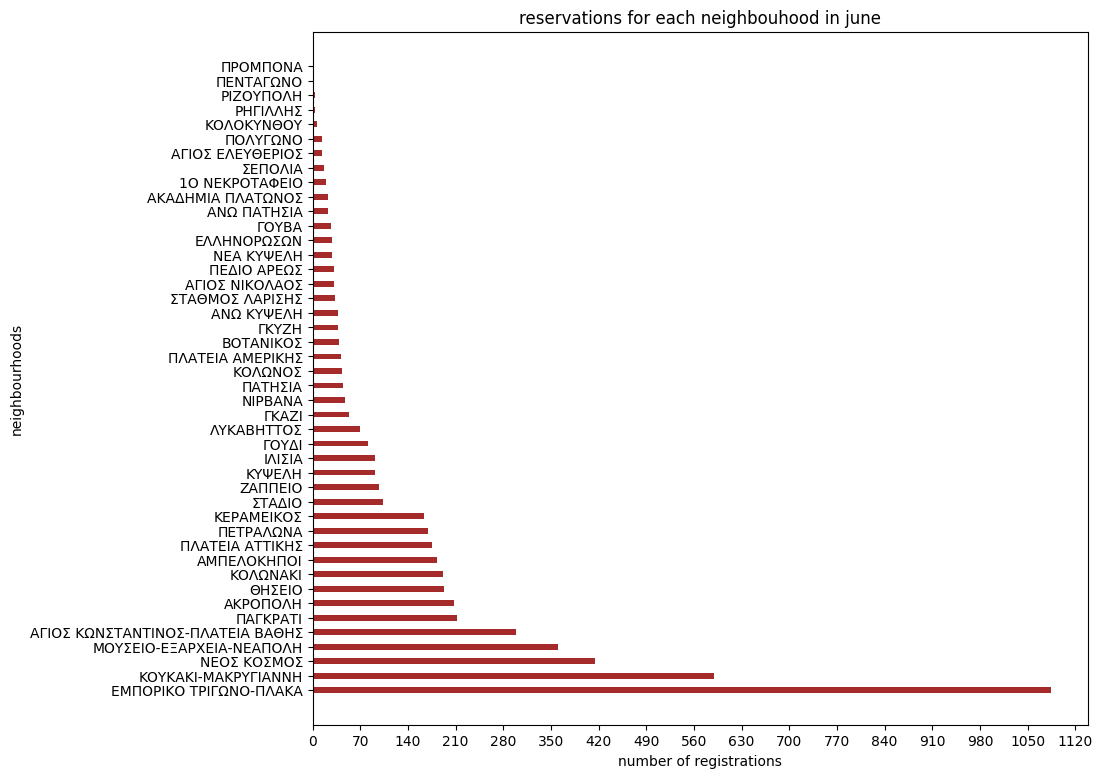

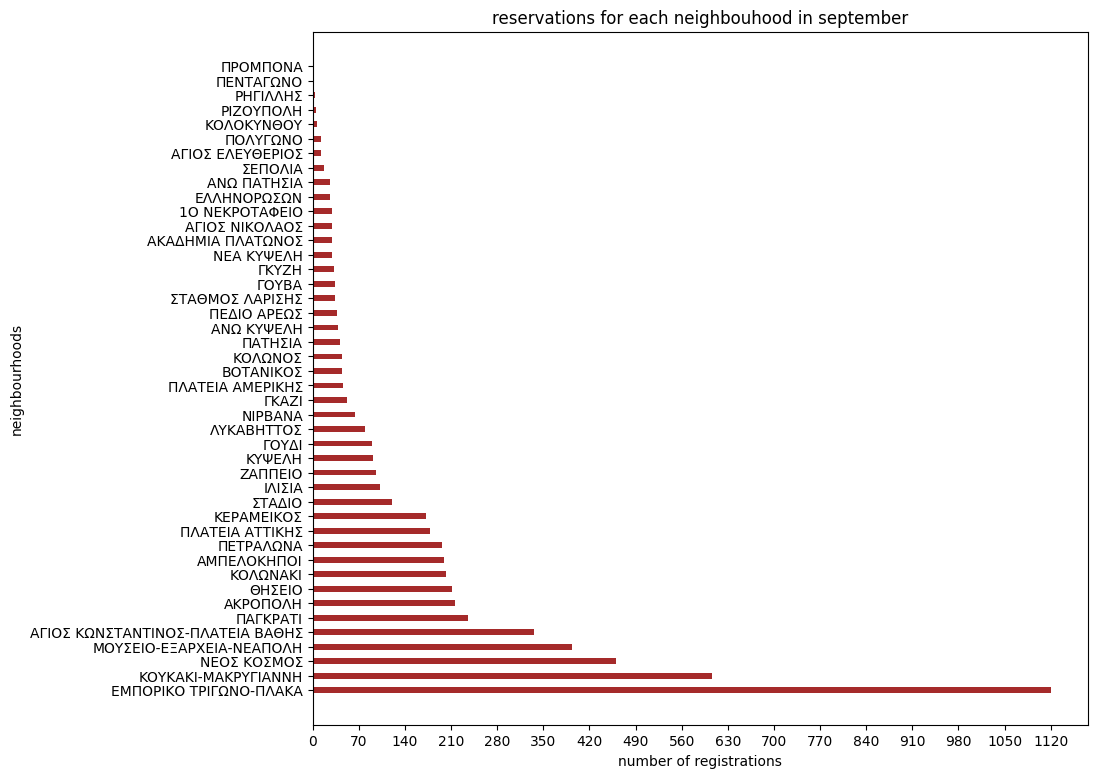

In [ ]:
#EROTIMA 1.5
df = pd.read_csv('train_2023.csv')

reg_df = df.groupby(['month', 'neighbourhood_cleansed']).size()

#make plot for every month
months = ['march', 'june', 'september']
for index,month in enumerate(months):
   monthly = reg_df[month].sort_values(ascending = False)
   plt.figure(figsize=(10, 9))
   plt.barh(monthly.index, monthly.values, color = 'brown', height = 0.4)
   plt.xlabel("number of registrations")
   plt.ylabel("neighbourhoods")
   plt.title('reservations for each neighbouhood in ' + month)
   max_x = monthly.max()
   plt.xticks(range(0, max_x+70, 70))
   name = 'question_1_5_' + str(index + 1) + '.png'

   #save plot
   plt.savefig(name)

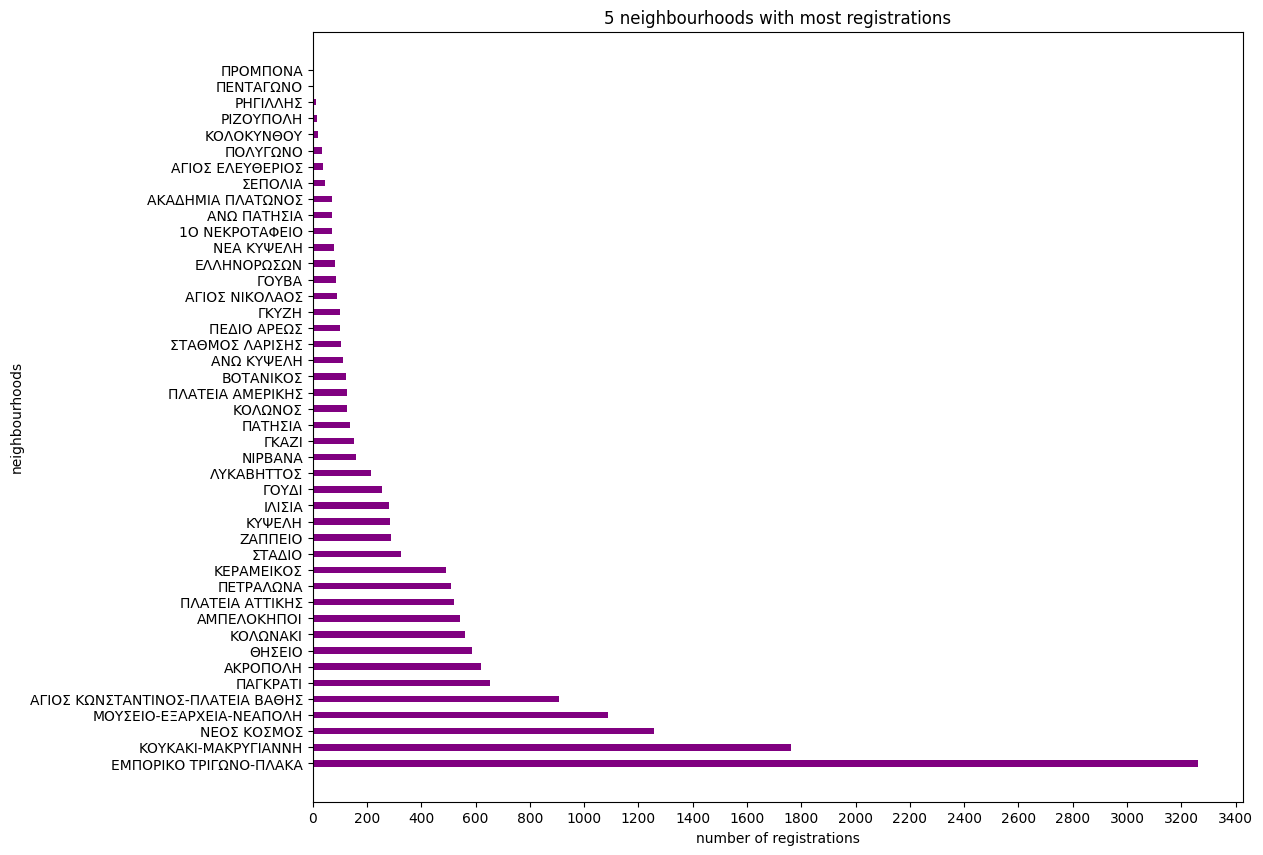

In [ ]:
#EROTIMA 1.6
df = pd.read_csv('train_2023.csv')

top_neighbourhoods = df['neighbourhood_cleansed'].value_counts()

#make plot
plt.figure(figsize=(12, 10))
plt.barh(top_neighbourhoods.index, top_neighbourhoods.values, color = 'purple', height = 0.4)
plt.xlabel("number of registrations")
plt.ylabel("neighbourhoods")
plt.title('5 neighbourhoods with most registrations')
max_x = top_neighbourhoods.max()
plt.xticks(range(0, max_x+200, 200))

#save plot
plt.savefig('question_1_6.png')

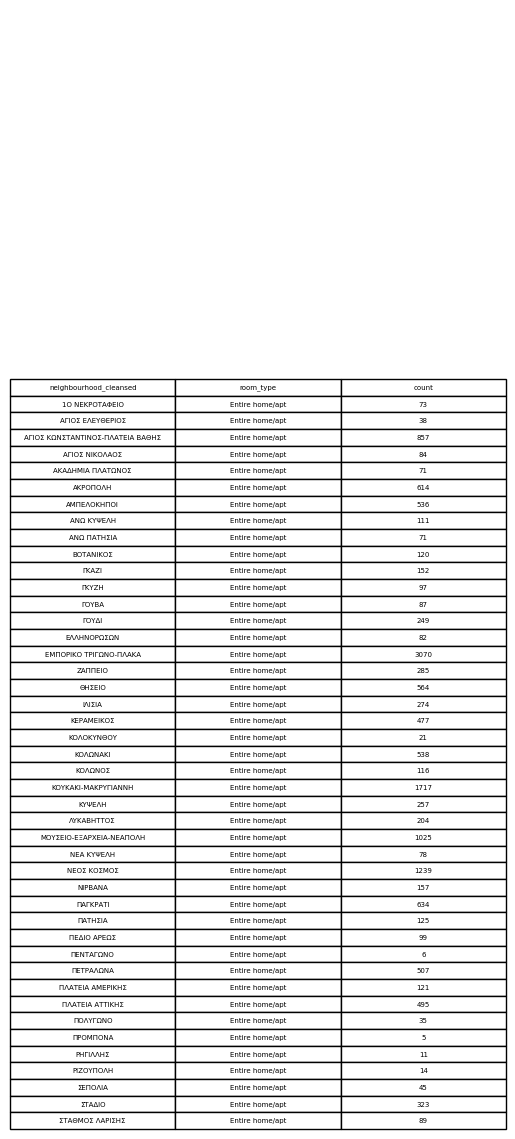

In [ ]:
#EROTIMA 1.7
df = pd.read_csv('train_2023.csv')

#make new column 'count'
freq_df = df.groupby(['neighbourhood_cleansed', 'room_type']).size().reset_index()
freq_df.columns = ['neighbourhood_cleansed', 'room_type', 'count']

#find indexes of most frequent room type for every neighbourhood in freq_df
room_indexes = freq_df.groupby('neighbourhood_cleansed')['count'].idxmax().values

#find data about room_types with the above indexes
room_types = freq_df.loc[room_indexes]

fig, ax = plt.subplots(1, 1)
ax.axis('off')

#make table
ax.table(cellText=room_types.values, colLabels=['neighbourhood_cleansed', 'room_type', 'count'],
         cellLoc = 'center')

#save table
plt.savefig('question_1_7.png')

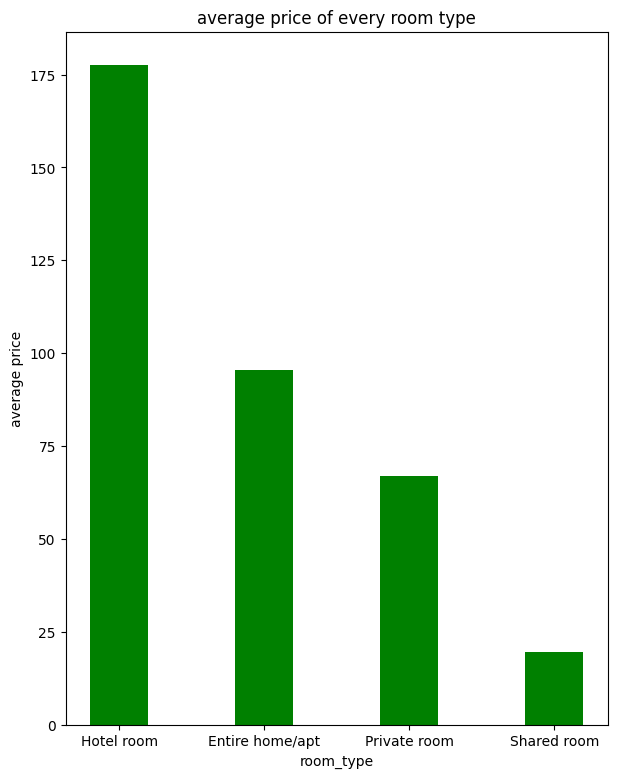

In [ ]:
#EROTIMA 1.8
df = pd.read_csv('train_2023.csv')

avg_prices_df = df.groupby('room_type')['price'].mean().sort_values(ascending = False)

#make plot
plt.figure(figsize=(7, 9))
plt.bar(avg_prices_df.index, avg_prices_df.values, color='green', width = 0.4)
plt.xlabel('room_type')
plt.ylabel('average price')
plt.title('average price of every room type')

#save plot
plt.savefig('question_1_8.png')

In [ ]:
#EROTIMA 1.9
df = pd.read_csv('train_2023.csv')

#I take the first 1500 because with more data it gets stuck
month_df = df[df['month'] == 'june'].head(1500)

#make map
mapp = folium.Map(location=[month_df['latitude'].mean(), month_df['longitude'].mean()], zoom_start=12.5)

#function to make a marker for every property
def make_marker(row):
    popup_info = f"Room Type: {row['room_type']}, Review Scores Rating: {row['review_scores_rating']}, Name: {row['name']}"
    map_popup = folium.Popup(popup_info, max_width=400)
    marker = folium.Marker(location=[row['latitude'], row['longitude']], popup = map_popup)
    marker.add_to(mapp)

#apply make_marker function to every row in the new DataFrame called month_df
month_df.apply(make_marker, axis=1)

#save map
mapp.save('question_1_9.html')

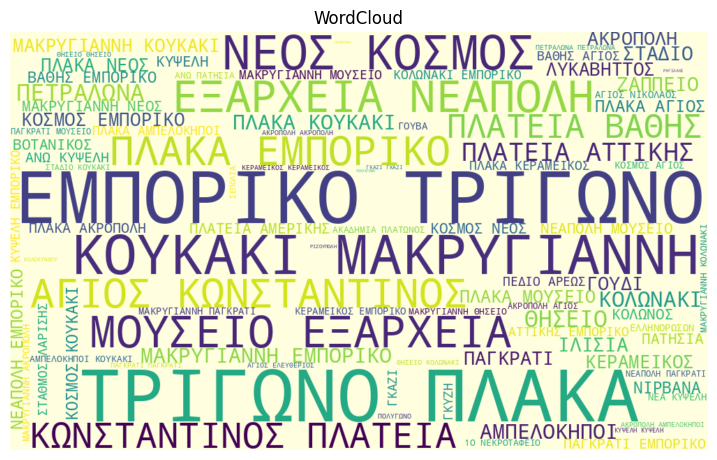

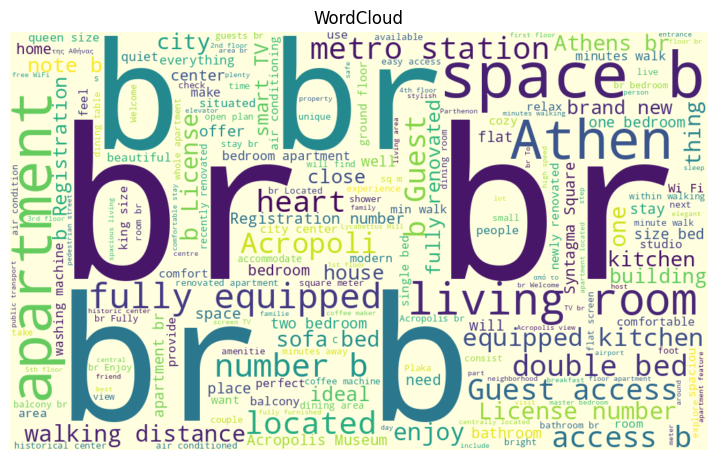

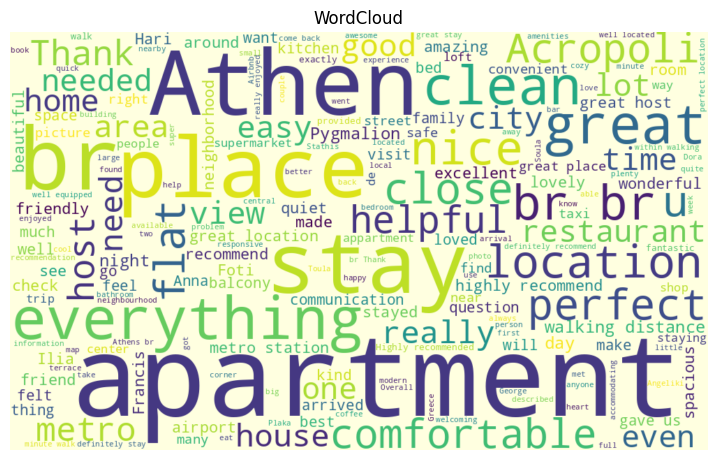

In [ ]:
#EROTIMA 1.10

def make_wordcloud(context, count):

  #make word cloud
  wc = WordCloud(width=1000, height=600, background_color='lightyellow').generate(context)
  plt.figure(figsize=(9, 7))
  plt.imshow(wc, interpolation='bilinear')
  plt.axis('off')
  plt.title('WordCloud')

  #save plot
  plt.savefig('question_1_10_' + str(count) + '.png')

df = pd.read_csv('train_2023.csv')

#make wordclouds for every column asked.
count = 1
context = ' '.join(df['neighbourhood_cleansed'])
make_wordcloud(context, count)
count = count + 1
context = ' '.join(df['description'])
make_wordcloud(context, count)
count = count + 1
context = ' '.join(reviews_2023_df['comments'].astype(str))
make_wordcloud(context, count)

In [ ]:
#EROTIMA 1.11
#Αναφέρθηκε στο eclass στη συζήτηση στον παρακάτω σύνδεσμο ότι επειδή είναι πάρα πολλές οι ανέσεις για να τις μετρήσουμε,
#μπορούμε να κάνουμε το ερώτημα μόνο για ένα έτος. Το κάναμε για το έτος 2019.
#https://eclass.uoa.gr/modules/forum/viewtopic.php?course=D424&topic=37715&forum=73089

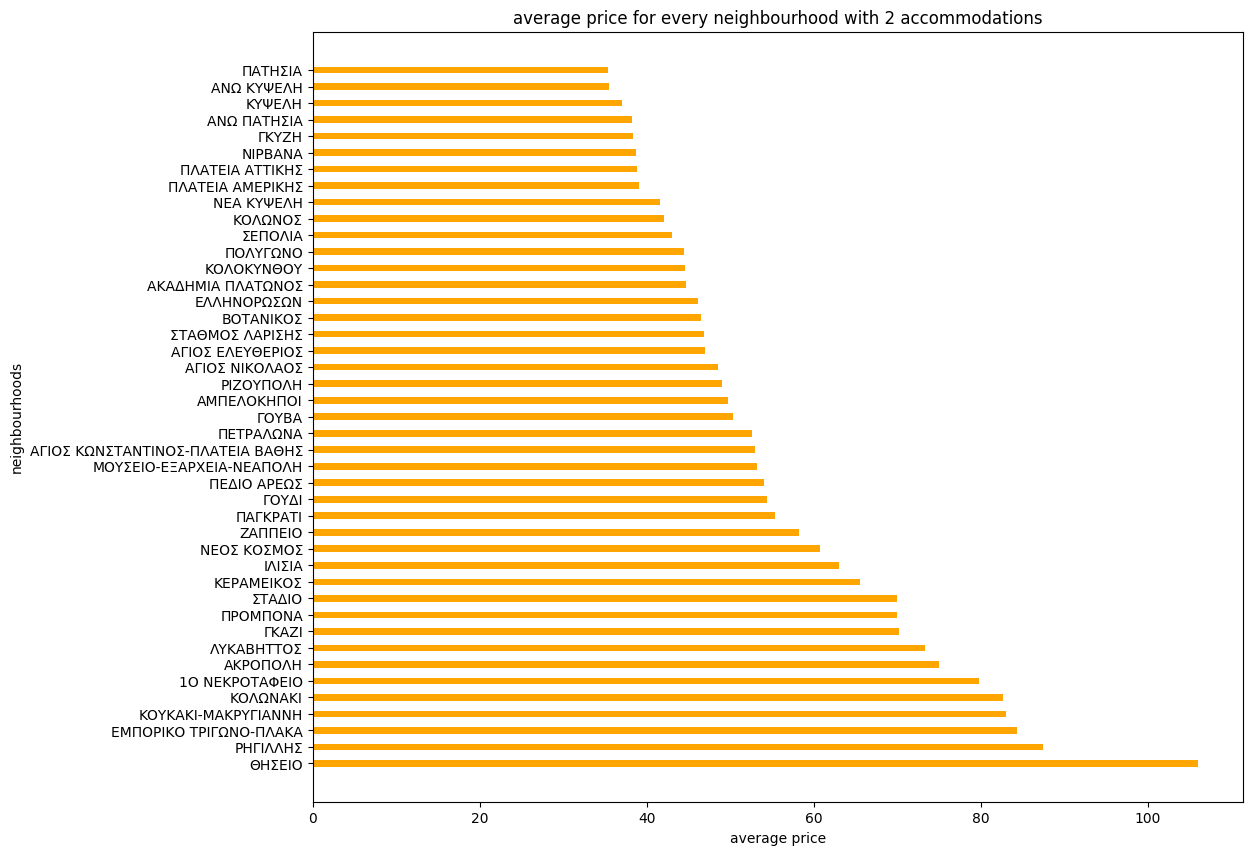

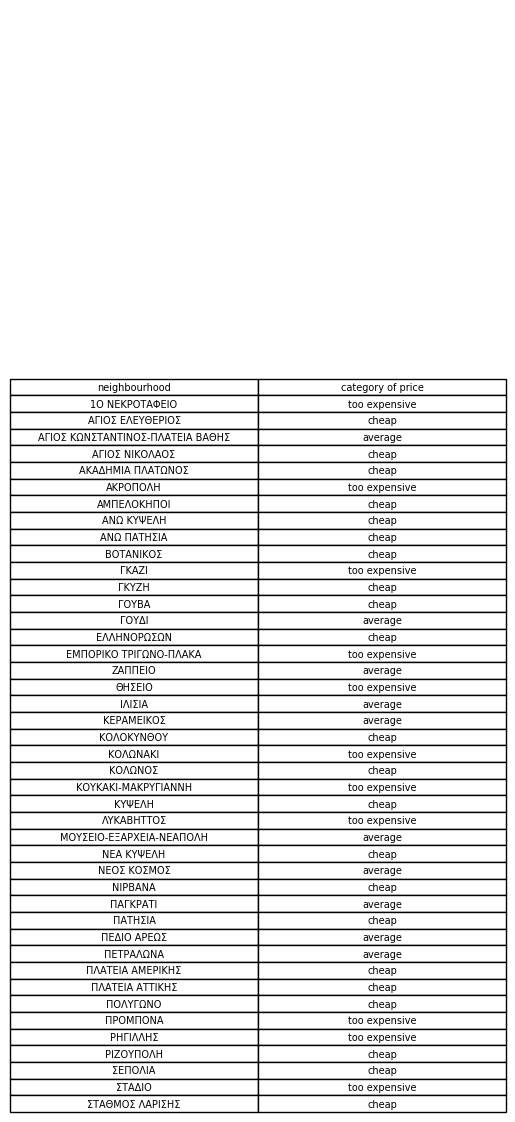

In [ ]:
#EROTIMA 1.12
df = pd.read_csv('train_2023.csv')

avg_df = df[df['accommodates'] == 2]
avg_df = avg_df.groupby('neighbourhood_cleansed')['price'].mean()
avg_df = avg_df.sort_values(ascending = False)

#make plot
plt.figure(figsize=(12, 10))
plt.barh(avg_df.index, avg_df.values, color = 'orange', height = 0.4)
plt.xlabel("average price")
plt.ylabel("neighbourhoods")
plt.title('average price for every neighbourhood with 2 accommodations')

#save plot
plt.savefig('question_1_12_histogram.png')

#define labels for the bins
new_labels = ['cheap', 'average', 'too expensive']

#define bins. cheap will be from the lowest price until the middle etc.
new_bins = [np.min(avg_df), np.percentile(avg_df, 50), np.percentile(avg_df, 75),
        np.max(avg_df)]

#change avg_df so it has a column which shows cheap oraverage or too expensive for every neighbourhood
avg_df = pd.cut(avg_df, bins = new_bins, labels = new_labels, include_lowest = True)

#get data
avg_df = avg_df.sort_index()
neighbourhoods = avg_df.index
price_categories = avg_df.values
fig, ax = plt.subplots(1, 1)
ax.axis('off')

#make table
table_data = list(zip(neighbourhoods, price_categories))
ax.table(cellText=table_data, colLabels=['neighbourhood', 'category of price'],
         cellLoc = 'center')

#save table
plt.savefig('question_1_12_table.png')


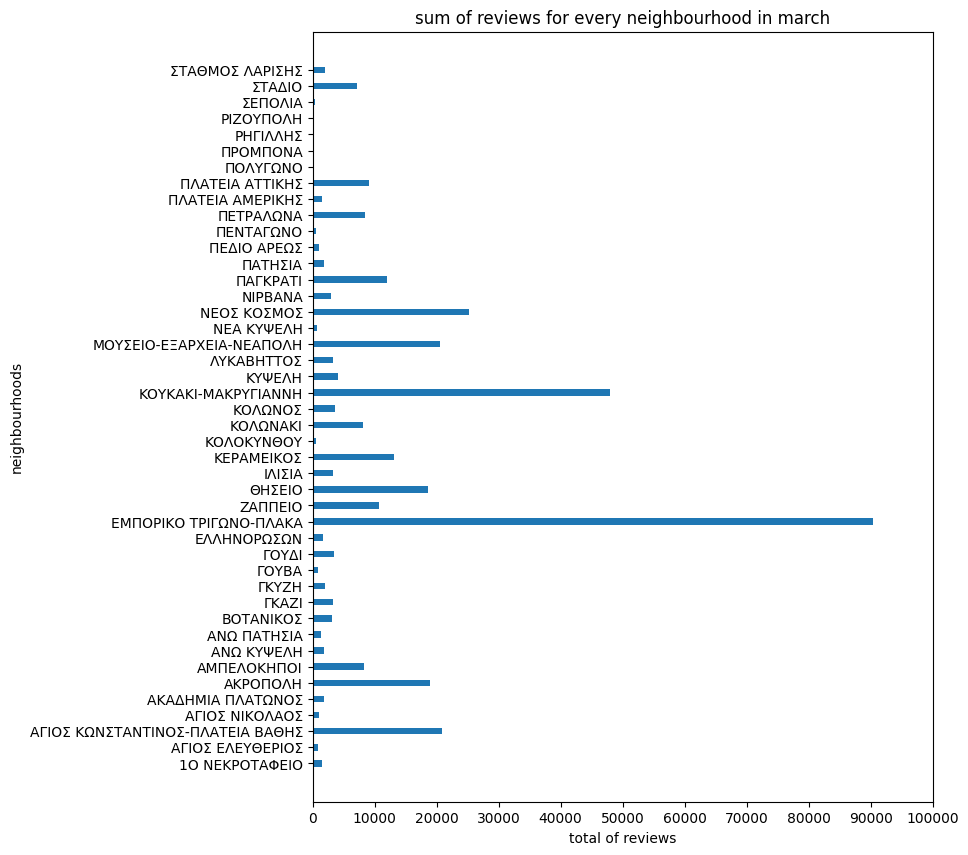

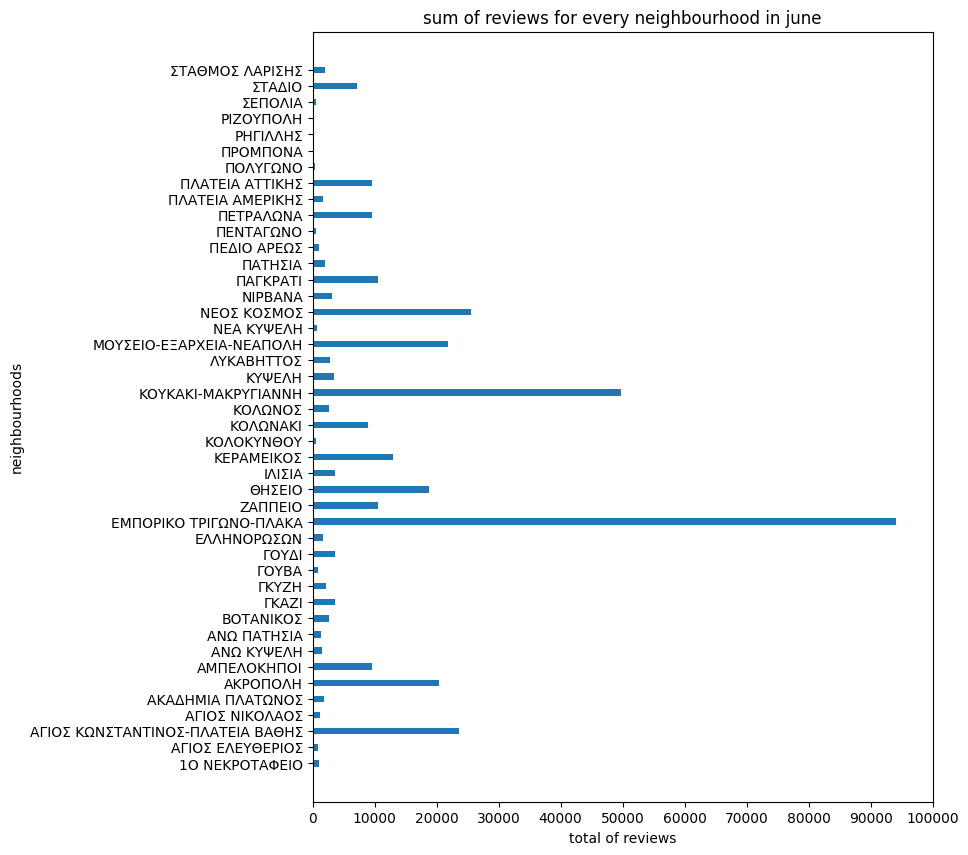

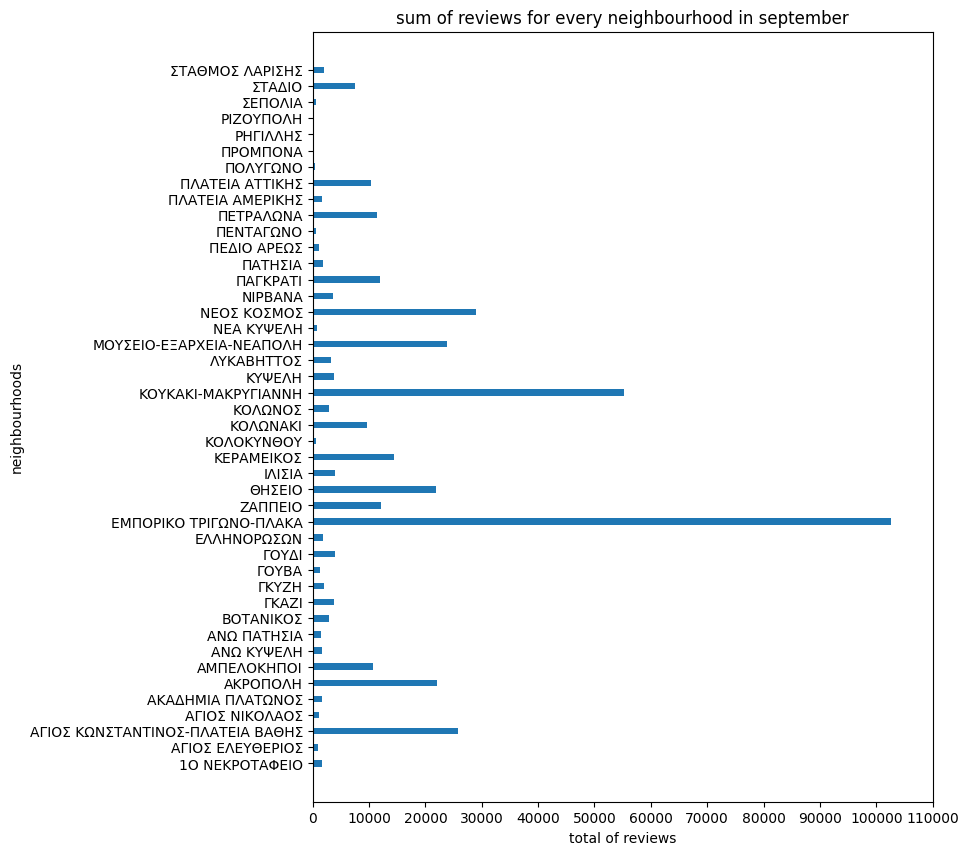

In [ ]:
#EROTIMA 1.13

#EROTIMA A: Σχεδιάστε διάγραμμα με τον αριθμό των κριτικών ανά γειτονιά ανά μήνα
df = pd.read_csv('train_2023.csv')

for index, month in enumerate(['march', 'june', 'september']):
  review_df = df[df['month'] == month]
  review_df = review_df.groupby('neighbourhood_cleansed')['number_of_reviews'].sum()

  #make plot
  plt.figure(figsize=(8, 10))
  plt.barh(review_df.index, review_df.values, height = 0.4)
  max_x = review_df.max()
  plt.xticks(range(0, max_x+10000, 10000))
  plt.xlabel('total of reviews')
  plt.ylabel('neighbourhoods')
  plt.title('sum of reviews for every neighbourhood in '+ str(month))

  #save plot
  plt.savefig('question_1_13A_' + str(index + 1) + '.png')

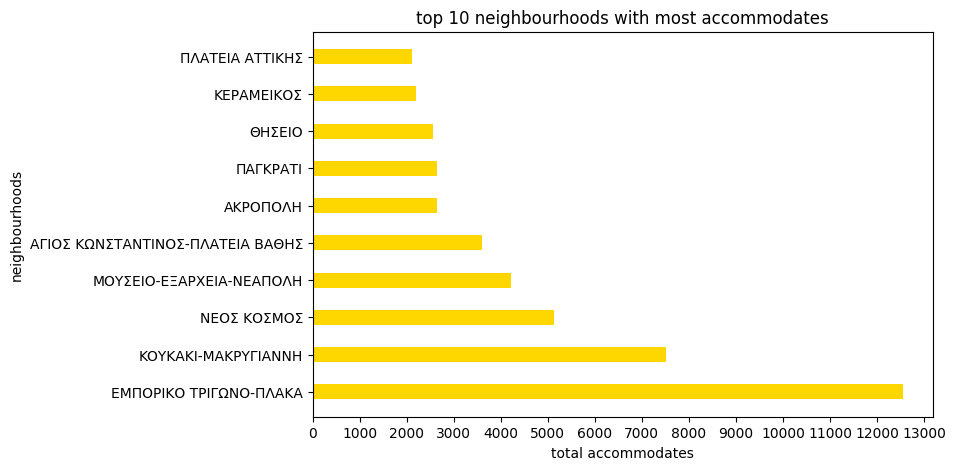

In [ ]:
#EROTIMA 1.13

#EROTIMA Β: Σχεδιάστε διάγραμμα με τις πρώτες 10 γειτονιές που μπορούν να φιλοξενήσουν τα περισσότερα άτομα
df = pd.read_csv('train_2023.csv')

accom_df = df.groupby('neighbourhood_cleansed')['accommodates'].sum()

accom_df = accom_df.sort_values(ascending=False).head(10)

#make plot
plt.figure(figsize=(8, 5))
plt.barh(accom_df.index, accom_df.values, color = 'gold', height = 0.4)
max_x = accom_df.max()
plt.xticks(range(0, max_x+1000, 1000))
plt.xlabel("total accommodates")
plt.ylabel("neighbourhoods")
plt.title('top 10 neighbourhoods with most accommodates')

#save plot
plt.savefig('question_1_13B.png')

In [ ]:
#EROTIMA 1.13

#EROTIMA C: Βρείτε το id, τη τιμή και τον μήνα του πιο ακριβού διαμερίσματος
df = pd.read_csv('train_2023.csv')

#make new indexes and drop the old ones
df = df.reset_index(drop=True)

#find index of most expensive property
max_index = df['price'].idxmax()

#get data of row with index == max_index
max_res = df.loc[max_index]

#print the information asked
print('id is:', max_res['id'])
print('price is:', max_res['price'])
print('month is:', max_res['month'])

id is: 572568549071124180
price is: 929.0
month is: september


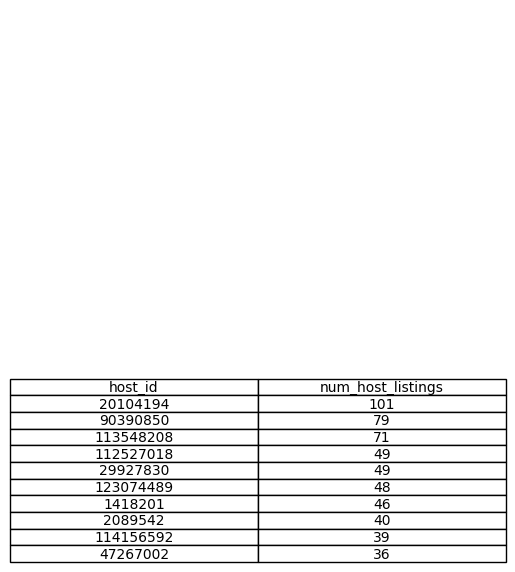

In [ ]:
#EROTIMA 1.14
df = pd.read_csv('train_2023.csv')

#find top 10 hosts with most properties
host_df = df.groupby('host_id')['id'].nunique()
host_df = host_df.sort_values(ascending = False).head(10)

fig, ax = plt.subplots(1, 1)
ax.axis('off')

#make table
ax.table(cellText=list(zip(host_df.index, host_df.values)), colLabels=['host_id', 'num_host_listings'],
         cellLoc = 'center')

#save plot
plt.savefig('question_1_14.png')

#EROTIMA 1.15
Απαντήθηκε στο έτος 2019.

In [ ]:
#EROTIMA 2.3
def recommend(item_id, num):

  if item_id not in df.index:
    print("Id you gave does not exist.")
    return

  #get the first num similar indexes for the item_id given
  similar_indexes = similarity_dict[item_id][:num]

  name_id = df.loc[item_id, 'name']
  print(f"Recommending {num} listings similar to {name_id}")
  print("--------------------")
  print()

  for index in similar_indexes:
    name = df.iloc[index]['name']
    description = df.iloc[index]['description']
    similarity_score = similarity[item_id][index]
    print(f"Recommended: {name}")
    print(f"Description: {description}")
    print(f"(score: {similarity_score})")
    print()

In [ ]:
#EROTIMA 2.1
df = pd.read_csv('train_2023.csv')

#create new column 'name description' from columns 'name' and 'description' and fill NA with NULL
df['name_description'] = df['name'].fillna('NULL') + ' ' + df['description'].fillna('NULL')

#remove duplicates from 'name description'
df.drop_duplicates(subset='name_description', inplace=True)

#get rid of STOP_WORDS and create the TF-IDF matrix
tfidf_vectorizer = TfidfVectorizer(stop_words = list(text.ENGLISH_STOP_WORDS), ngram_range = (1, 2))
tfidf_matrix = tfidf_vectorizer.fit_transform(df['name_description'])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns = tfidf_vectorizer.get_feature_names_out())

#print top 5 words that visitors use for Athens
most_used_words = tfidf_df.sum().sort_values(ascending = False).head(5)
print('Top 5 most used words are:')
print(most_used_words)

#EROTIMA 2.2
#make the tfidf values to a CSR sparse matrix
sparse = csr_matrix(tfidf_df.values)

#take the tfidf indexes
indexes = tfidf_df.index
similarity_dict = {}

#compute cosine similarity between all combinations
similarity = cosine_similarity(sparse)

for item_id in indexes:
  #get similarities for each item_id
  similarities = similarity[item_id]

  #sort similarities in ascending order
  similarities = np.argsort(similarities)

  #reverse them so they will be in descending order
  similarities = similarities[::-1]

  #take the first 101 items
  similarities = similarities[:101]

  #remove the case index == item_id
  similarity_dict[item_id] = [index for index in similarities if index != item_id]

#get rid of every id that not exists in DataFrame
similarity_dict = {item_id: similarities for item_id, similarities in similarity_dict.items() if item_id in df.index}

item_id = int(random.choice(list(similarity_dict.keys())))
num = int(input("How many recommandations do you want? "))
recommend(item_id, num)

#EROTIMA 2.4
#make all uppercase letters to lowercase
df_lower = df['name_description'].str.lower()

#seperate all words by whitespace
all_words = df_lower.str.split()

#make all lists of words into one big list
words = []
for list_words in all_words:
    for word in list_words:
        words.append(word)

#remove stopwords from words
stop_words = set(text.ENGLISH_STOP_WORDS)
words_without_stopwords = []

for word in words:
  if word not in stop_words:
    words_without_stopwords.append(word)

#find top 10 matching words
finder = BigramCollocationFinder.from_words(words_without_stopwords)
bigram_measures = BigramAssocMeasures()
collocations = finder.nbest(bigram_measures.raw_freq, 10)
print('Top 10 collocations of words are:')
print(collocations)

Top 5 most used words are:
br           1625.318916
br br         480.072193
apartment     476.653572
athens        336.515730
bed           289.222946
dtype: float64
How many recommandations do you want? 15
Recommending 15 listings similar to Rental unit in Athina · ★4.87 · 1 bedroom · 1 bed · 1 bath
--------------------

Recommended: Condo in Athina · ★4.97 · 1 bedroom · 3 beds · 1 bath
Description: Το διαμερισμα είναι σε καινούργια πολυκατοικία πρόσβαση χωρίς σκαλοπάτια έχει ασανσέρ ειναι στο 2ο όροφο.Με ένα φωτεινό υπνοδωμάτιο με διπλό κρεβάτι, smartTV32.Κουζίνα-σαλόνι που έχει καναπέ-κρεββάτι και πολυθρόνα-κρεββάτι, γρήγορο internet και smartTV42. Ευρύχωρο μπάνιο, πλυντήριο ρούχων και μεγάλη βεράντα για να απολαμβάνετε τον καφέ σας. Καλωσόρισμα με κρασί, πρωινό καφέ, μαρμελάδα, βούτυρο φρυγανιές. Στην ήσυχη-trendy περιοχή του Αγ. Γεωργίου Κυψέλης! Στα 200μ αφετηρία για Σούνιο &παραλίες !<br /><br /><b>The space</b><br />Το διαμερισμα ειναι συγχρονο και Πλήρως ανακαινισμένο διαθέτε